<a href="https://colab.research.google.com/github/sheekhaa/AI-worksheets/blob/main/worksheet2_basanti.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

```
# 5CS037: Concepts and Technologies of AI
# Name: Basanti Kandel
# Level: 5
# Group: L5CG10
# Student ID:2510348
```



In [3]:
#Problem 1 - Data Read, Write and Inspect:
#Dataset for the Task: "bank.csv"
# 1. Load the provided dataset and import in pandas DataFrame.
import pandas as pd

bank_path = "/content/drive/MyDrive/Colab Notebooks/Dataset/bank.csv"
bank_dataframe = pd.read_csv(bank_path)

bank_dataframe.head()


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
# 2. Check info of the DataFrame and identify following:
# (a) columns with dtypes=object
# (b) unique values of those columns.
# (c) check for the total number of null values in each column.

bank_dataframe.info()
# (a) columns with dtype = object
object_cols = bank_dataframe.select_dtypes(include='object').columns
print("Object columns:", object_cols)

# (b) unique values of object columns
for col in object_cols:
    print(f"\nUnique values in {col}:")
    print(bank_dataframe[col].unique())

# (c) total null values
print("\nNull values in each column:")
print(bank_dataframe.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB
Object columns: Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
    

In [5]:
# Drop all the columns with dtypes object and store in new DataFrame, also write the DataFrame in
# ”.csv” with name ”banknumericdata.csv”
bank_numeric = bank_dataframe.drop(columns=object_cols)

bank_numeric.to_csv("banknumericdata.csv", index=False)
print("File saved successfully!")


File saved successfully!


In [8]:
# 4. Read ”banknumericdata.csv” and Find the summary statistics.
bank_numeric_read = pd.read_csv("banknumericdata.csv")
bank_numeric_read.describe()


,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [10]:
# Problem 2 - Data Imputations:
# Dataset for the Task: "medical_student.csv"
# 1. Load the provided dataset and import in pandas DataFrame.
med_path = "/content/drive/MyDrive/Colab Notebooks/Dataset/medical_students_dataset.csv"
med_dataframe = pd.read_csv(med_path)

med_dataframe.head()


,Student ID,Age,Gender,Height,Weight,Blood Type,BMI,Temperature,Heart Rate,Blood Pressure,Cholesterol,Diabetes,Smoking
0,1.0,18.0,Female,161.777924,72.354947,O,27.645835,NaN,95.0,109.0,203.0,No,NaN
1,2.0,NaN,Male,152.069157,47.630941,B,NaN,98.714977,93.0,104.0,163.0,No,No
2,3.0,32.0,Female,182.537664,55.741083,A,16.729017,98.260293,76.0,130.0,216.0,Yes,No
3,NaN,30.0,Male,182.112867,63.332207,B,19.096042,98.839605,99.0,112.0,141.0,No,Yes
4,5.0,23.0,Female,NaN,46.234173,O,NaN,98.480008,95.0,NaN,231.0,No,No


In [11]:
# 2. Check info of the DataFrame and identify column with missing (null) values.
med_dataframe.info()
med_dataframe.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 13 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Student ID      180000 non-null  float64
 1   Age             180000 non-null  float64
 2   Gender          180000 non-null  object 
 3   Height          180000 non-null  float64
 4   Weight          180000 non-null  float64
 5   Blood Type      180000 non-null  object 
 6   BMI             180000 non-null  float64
 7   Temperature     180000 non-null  float64
 8   Heart Rate      180000 non-null  float64
 9   Blood Pressure  180000 non-null  float64
 10  Cholesterol     180000 non-null  float64
 11  Diabetes        180000 non-null  object 
 12  Smoking         180000 non-null  object 
dtypes: float64(9), object(4)
memory usage: 19.8+ MB


,0
Student ID,20000
Age,20000
Gender,20000
Height,20000
Weight,20000
Blood Type,20000
BMI,20000
Temperature,20000
Heart Rate,20000
Blood Pressure,20000


In [12]:
# 3. For the column with missing values fill the values using various techniques we discussed above. Try
# to explain why did you select the particular methods
for col in med_dataframe.columns:
    if med_dataframe[col].isnull().sum() > 0:
        if med_dataframe[col].dtype == 'object':
            med_dataframe[col] = med_dataframe[col].fillna(med_dataframe[col].mode()[0])
            print(f"{col} → filled with MODE")
        else:
            # choose median for numeric
            med_dataframe[col] = med_dataframe[col].fillna(med_dataframe[col].median())
            print(f"{col} → filled with MEDIAN")


Student ID → filled with MEDIAN
Age → filled with MEDIAN
Gender → filled with MODE
Height → filled with MEDIAN
Weight → filled with MEDIAN
Blood Type → filled with MODE
BMI → filled with MEDIAN
Temperature → filled with MEDIAN
Heart Rate → filled with MEDIAN
Blood Pressure → filled with MEDIAN
Cholesterol → filled with MEDIAN
Diabetes → filled with MODE
Smoking → filled with MODE


In [13]:
# 4. Check for any duplicate values present in Dataset and do necessary to manage the duplicate items.
# {Hint: dataset.duplicated.sum()}
duplicates = med_dataframe.duplicated().sum()
print("Total duplicates:", duplicates)

med_df = med_dataframe.drop_duplicates()
print("Duplicates removed.")


Total duplicates: 12879
Duplicates removed.


In [14]:
# Exercises - Data Cleaning and Transformations with ”Titanic Dataset”:
# Problem - 1:
# Create a DataFrame that is subsetted for the columns ’Name’, ’Pclass’, ’Sex’, ’Age’, ’Fare’, and ’Survived’.
# Retain only those rows where ’Pclass’ is equal to 1, representing first-class passengers. What is the mean,
# median, maximum value, and minimum value of the ’Fare’ column?
titanic_path = "/content/drive/MyDrive/Colab Notebooks/Dataset/Titanic-Dataset.csv"
titanic_dataframe = pd.read_csv(titanic_path)

titanic_dataframe.head()
subset = titanic_dataframe[['Name','Pclass','Sex','Age','Fare','Survived']]

first_class = subset[subset['Pclass'] == 1]
mean_fare = first_class['Fare'].mean()
median_fare = first_class['Fare'].median()
max_fare = first_class['Fare'].max()
min_fare = first_class['Fare'].min()

mean_fare, median_fare, max_fare, min_fare



(np.float64(84.1546875), 60.287499999999994, 512.3292, 0.0)

In [15]:
# Problem - 2:
# How many null values are contained in the ’Age’ column in your subsetted DataFrame? Once you’ve found
# this out, drop them from your DataFrame.
null_ages = first_class['Age'].isnull().sum()
print("Null Age values:", null_ages)

first_class_clean = first_class.dropna(subset=['Age'])
first_class_clean.shape



Null Age values: 30


(186, 6)

In [18]:
# Problem - 3:
# The ’Embarked’ column in the Titanic dataset contains categorical data representing the ports of
# embarkation:
# • ’C’ for Cherbourg
# • ’Q’ for Queenstown
# • ’S’ for Southampton
# Task:
# 1. Use one-hot encoding to convert the ’Embarked’ column into separate binary columns (’Embarked C’,
# ’Embarked Q’, ’Embarked S’).
# 2. Add these new columns to the original DataFrame.
# 3. Drop the original ’Embarked’ column.
# 4. Print the first few rows of the modified DataFrame to verify the changes.

#1
embarked_dummies = pd.get_dummies(titanic_dataframe['Embarked'], prefix="Embarked")

# 2
titanic_mod = pd.concat([titanic_dataframe, embarked_dummies], axis=1)

# 3
del titanic_mod['Embarked']
print(titanic_mod.head())


   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin  Embarked_C  Embarked_Q  Embarked_S  
0      0         A/5 21171   7.2500   NaN       False       False        True  
1      0          PC 17599  71.2833   C85        True       False       False  
2      0  STON/O2. 3101282   7.9250   NaN       False       False        True  


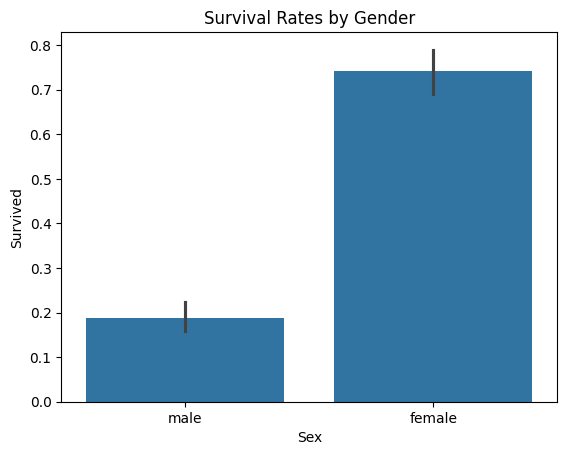

In [17]:
# Problem - 4:
# Compare the mean survival rates (’Survived’) for the different groups in the ’Sex’ column. Draw a visual-
# ization to show how the survival distributions vary by gender.
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=titanic_dataframe, x='Sex', y='Survived')
plt.title("Survival Rates by Gender")
plt.show()


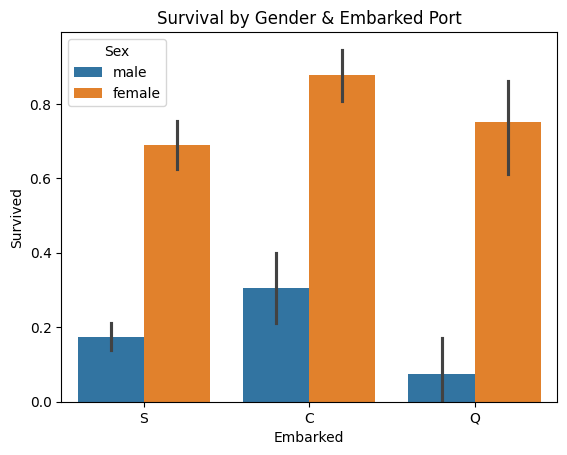

In [ ]:
# Problem - 5:
# Draw a visualization that breaks your visualization from Exercise 3 down by the port of embarkation (’Em-
# barked’). In this instance, compare the ports ’C’ (Cherbourg), ’Q’ (Queenstown), and ’S’ (Southampton).
sns.barplot(data=titanic_dataframe, x='Embarked', y='Survived', hue='Sex')
plt.title("Survival by Gender & Embarked Port")
plt.show()
